# 2D Mesh GRF Ablation

Synthetic ablation study on a 2D grid using the current `grf_gp` library.

In [135]:
%load_ext autoreload
%autoreload 2

import os
import sys

import gpytorch
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import torch

project_root = os.path.abspath('../..')
sys.path.append(project_root)

from grf_gp.kernels.diffusion import DiffusionExactKernel
from grf_gp.kernels.general import GeneralGRFKernel
from grf_gp.model import ExactGraphGP, GRFGP
from grf_gp.sampler import GRFSampler
from grf_gp.utils.spectral import get_normalized_laplacian

from experiments.utils import evaluate_model, train_model
from grf_ablation_sampler import GRFAblationSampler

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
dtype = torch.float64

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [136]:
MESH_SIZE = 30
NUM_NODES = MESH_SIZE ** 2
BETA_SAMPLE = 40.0
KERNEL_VARIANCE = 10.0
NOISE_STD = 0.1
TRAIN_FRACTION = 0.2
SEED = 1

WALKS_PER_NODE = 10000
P_HALT = 0.01
MAX_WALK_LENGTH = 8

TRAIN_LR = 0.05
TRAIN_ITERS = 500

In [137]:
np.random.seed(SEED)
torch.manual_seed(SEED)

def make_grid_graph(mesh_size):
    graph = nx.grid_2d_graph(mesh_size, mesh_size)
    adjacency = nx.to_numpy_array(graph, dtype=np.float64)
    return graph, adjacency


def sample_diffusion_field(L, beta, sigma_f, noise_std, seed):
    torch.manual_seed(seed)
    cov = sigma_f ** 2 * torch.matrix_exp(-beta * L)
    jitter = 1e-6 * torch.eye(L.size(0), dtype=L.dtype, device=L.device)
    latent = torch.distributions.MultivariateNormal(
        loc=torch.zeros(L.size(0), dtype=L.dtype, device=L.device),
        covariance_matrix=cov + jitter,
    ).sample()
    noisy = latent + noise_std * torch.randn_like(latent)
    return latent, noisy


def plot_field(values, mesh_size, title, cmap='plasma', observed_idx=None):
    grid = values.reshape(mesh_size, mesh_size)
    plt.figure(figsize=(6, 5))
    plt.imshow(grid, cmap=cmap, origin='lower')
    if observed_idx is not None:
        y = observed_idx // mesh_size
        x = observed_idx % mesh_size
        plt.scatter(x, y, s=8, c='black')
    plt.title(title)
    plt.colorbar(fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.show()


def fit_exact_diffusion(x_train, y_train, L):
    likelihood = gpytorch.likelihoods.GaussianLikelihood().to(device=device, dtype=dtype)
    kernel = DiffusionExactKernel(L).to(device=device, dtype=dtype)
    model = ExactGraphGP(x_train, y_train, likelihood, kernel).to(device=device, dtype=dtype)
    train_model(model, likelihood, x_train, y_train, lr=TRAIN_LR, max_iter=TRAIN_ITERS, progress_desc='Exact diffusion')
    return model, likelihood, kernel


def fit_grf_model(x_train, y_train, kernel_cls, rw_mats):
    likelihood = gpytorch.likelihoods.GaussianLikelihood().to(device=device, dtype=dtype)
    kernel = kernel_cls(rw_mats, MAX_WALK_LENGTH).to(device=device, dtype=dtype)
    model = GRFGP(x_train, y_train, likelihood, kernel).to(device=device, dtype=dtype)
    train_model(model, likelihood, x_train, y_train, lr=TRAIN_LR, max_iter=TRAIN_ITERS, progress_desc=kernel_cls.__name__)
    return model, likelihood, kernel

In [138]:
graph, adjacency_matrix = make_grid_graph(MESH_SIZE)
L_np = get_normalized_laplacian(adjacency_matrix)
L = torch.tensor(L_np, dtype=dtype, device=device)

latent_field, noisy_field = sample_diffusion_field(
    L=L,
    beta=BETA_SAMPLE,
    sigma_f=np.sqrt(KERNEL_VARIANCE),
    noise_std=NOISE_STD,
    seed=SEED,
)

all_idx = np.arange(NUM_NODES)
n_train = int(TRAIN_FRACTION * NUM_NODES)
train_idx = np.random.choice(NUM_NODES, size=n_train, replace=False)
test_idx = np.setdiff1d(all_idx, train_idx)

X_train = torch.tensor(train_idx, dtype=torch.long, device=device)
Y_train_raw = noisy_field[train_idx]
X_test = torch.tensor(test_idx, dtype=torch.long, device=device)
Y_test_raw = noisy_field[test_idx]
X_full = torch.tensor(all_idx, dtype=torch.long, device=device)

train_mean = Y_train_raw.mean()
train_std = Y_train_raw.std()
Y_train = ((Y_train_raw - train_mean) / train_std).flatten()
Y_test = ((Y_test_raw - train_mean) / train_std).flatten()


print(f'num_nodes: {NUM_NODES}')
print(f'n_train: {len(train_idx)} | n_test: {len(test_idx)}')
print(f'train mean/std: {train_mean.item():.4f} / {train_std.item():.4f}')

num_nodes: 900
n_train: 180 | n_test: 720
train mean/std: 0.0693 / 0.3462


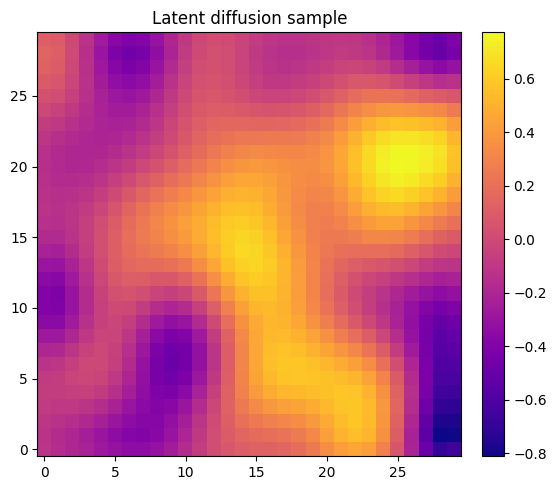

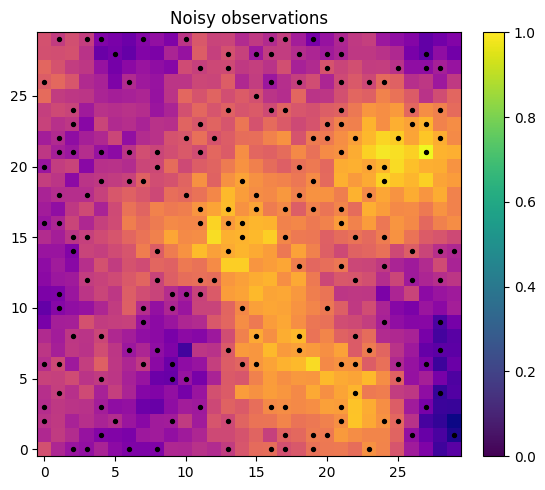

In [139]:
plot_field(latent_field.detach().cpu().numpy(), MESH_SIZE, 'Latent diffusion sample')
plot_field(noisy_field.detach().cpu().numpy(), MESH_SIZE, 'Noisy observations', observed_idx=train_idx)

## Random-Walk Features

In [140]:
sampler = GRFSampler(
    L,
    walks_per_node=WALKS_PER_NODE,
    p_halt=P_HALT,
    max_walk_length=MAX_WALK_LENGTH,
    seed=SEED,
    use_tqdm=True,
    n_processes=4,
)
rw_mats = sampler()

ablation_sampler = GRFAblationSampler(
    L,
    walks_per_node=WALKS_PER_NODE,
    p_halt=P_HALT,
    max_walk_length=MAX_WALK_LENGTH,
    seed=SEED,
    use_tqdm=True,
    n_processes=4,
)
rw_mats_ablation = ablation_sampler()

## Exact Diffusion

In [141]:
exact_model, exact_likelihood, exact_kernel = fit_exact_diffusion(X_train, Y_train, L)
lml_exact, rmse_exact, nlpd_exact = evaluate_model(
    exact_model,
    exact_likelihood,
    X_train,
    Y_train,
    X_test,
    Y_test,
    train_std,
)
with torch.no_grad():
    mean_exact = exact_model.predict(X_test).mean.detach().cpu().numpy()
print(f'Exact diffusion | LML: {lml_exact:.4f} | RMSE: {rmse_exact:.4f} | NLPD: {nlpd_exact:.4f}')
print(f'beta: {exact_kernel.beta.item():.4f} | sigma_f: {exact_kernel.sigma_f.item():.4f}')

Exact diffusion:   0%|          | 0/500 [00:00<?, ?it/s]

/Users/matthew/Documents/Efficient Gaussian Process on Graphs/Efficient_Gaussian_Process_On_Graphs/venv/lib/python3.11/site-packages/gpytorch/models/exact_gp.py:296: GPInputWarning: The input matches the stored training data. Did you forget to call model.train()?
  warnings.warn(


Exact diffusion | LML: -0.4972 | RMSE: 0.1209 | NLPD: 0.2761
beta: 13.8092 | sigma_f: 4.3522


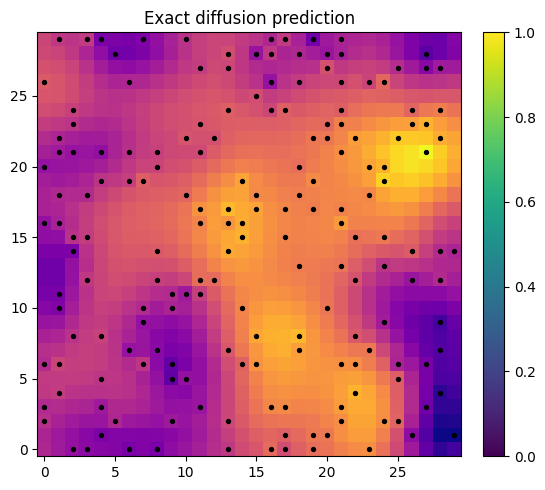

In [142]:
full_exact = np.zeros(NUM_NODES)
full_exact[train_idx] = Y_train_raw.detach().cpu().numpy()
full_exact[test_idx] = mean_exact * train_std.item() + train_mean.item()
plot_field(full_exact, MESH_SIZE, 'Exact diffusion prediction', observed_idx=train_idx)

## Learned GRF

In [143]:
grf_model, grf_likelihood, grf_kernel = fit_grf_model(X_train, Y_train, GeneralGRFKernel, rw_mats)
lml_grf, rmse_grf, nlpd_grf = evaluate_model(
    grf_model,
    grf_likelihood,
    X_train,
    Y_train,
    X_test,
    Y_test,
    train_std,
)
with torch.no_grad():
    mean_grf = grf_model.predict(X_test).mean.detach().cpu().numpy()
print(f'Learned GRF | LML: {lml_grf:.4f} | RMSE: {rmse_grf:.4f} | NLPD: {nlpd_grf:.4f}')
print('modulation:', grf_kernel.modulation_function.detach().cpu().numpy())

GeneralGRFKernel:   0%|          | 0/500 [00:00<?, ?it/s]

Learned GRF | LML: 217.7082 | RMSE: 0.1559 | NLPD: 0.6110
modulation: [-2.55877344e+00  4.68190575e+00 -1.29513800e+00 -5.98027541e-01
 -4.85878983e-02  5.38259488e-02  2.32415241e-03  1.11769894e-02]


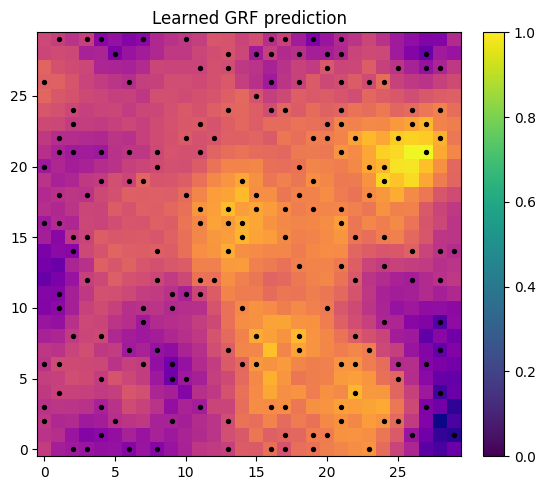

In [144]:
full_grf = np.zeros(NUM_NODES)
full_grf[train_idx] = Y_train_raw.detach().cpu().numpy()
full_grf[test_idx] = mean_grf * train_std.item() + train_mean.item()
plot_field(full_grf, MESH_SIZE, 'Learned GRF prediction', observed_idx=train_idx)

## Ablated GRF

This uses the same random-walk feature map as the learned GRF, but replaces the learnable modulation with a fixed uniform weighting across walk lengths.

In [145]:
abl_model, abl_likelihood, abl_kernel = fit_grf_model(X_train, Y_train, GeneralGRFKernel, rw_mats_ablation)
lml_abl, rmse_abl, nlpd_abl = evaluate_model(
    abl_model,
    abl_likelihood,
    X_train,
    Y_train,
    X_test,
    Y_test,
    train_std,
)
with torch.no_grad():
    mean_abl = abl_model.predict(X_test).mean.detach().cpu().numpy()
print(f'Ablated GRF | LML: {lml_abl:.4f} | RMSE: {rmse_abl:.4f} | NLPD: {nlpd_abl:.4f}')
print('modulation:', abl_kernel.modulation_function.detach().cpu().numpy())

GeneralGRFKernel:   0%|          | 0/500 [00:00<?, ?it/s]

Ablated GRF | LML: 285.5609 | RMSE: 0.1823 | NLPD: 0.7266
modulation: [ -2.11339294  11.89236832  -6.92112231 -13.33594455 -17.07223402
 -17.05885189 -17.24202728 -19.71172807]


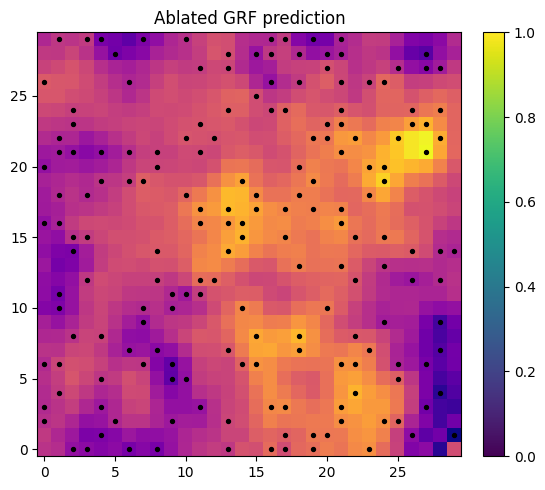

In [146]:
full_abl = np.zeros(NUM_NODES)
full_abl[train_idx] = Y_train_raw.detach().cpu().numpy()
full_abl[test_idx] = mean_abl * train_std.item() + train_mean.item()
plot_field(full_abl, MESH_SIZE, 'Ablated GRF prediction', observed_idx=train_idx)

In [147]:
import pandas as pd

pd.DataFrame(
    [
        {'model': 'Exact diffusion', 'lml': lml_exact, 'rmse': rmse_exact, 'nlpd': nlpd_exact},
        {'model': 'Learned GRF', 'lml': lml_grf, 'rmse': rmse_grf, 'nlpd': nlpd_grf},
        {'model': 'Ablated GRF', 'lml': lml_abl, 'rmse': rmse_abl, 'nlpd': nlpd_abl},
    ]
).round(4)

,model,lml,rmse,nlpd
0,Exact diffusion,-0.4972,0.1209,0.2761
1,Learned GRF,217.7082,0.1559,0.6110
2,Ablated GRF,285.5609,0.1823,0.7266
